Importing the required libraries for data analysis and visualization.

Импорт необходимых библиотек для анализа данных и визуализации.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
from os import environ
%matplotlib inline

Loading the primary dataset and the application description dataset.

Загрузка основного датасета и датасета с описаниями приложений.

In [2]:
environ["KAGGLEHUB_ANONYMOUS_DOWNLOAD"]='1'
filepath=kh.dataset_download("ramamet4/app-store-apple-data-set-10k-apps")
df1=pd.read_csv(f"{filepath}/AppleStore.csv")
df2=pd.read_csv(f"{filepath}/appleStore_description.csv")

100%|██████████| 5.63M/5.63M [00:00<00:00, 115MB/s]

Extracting files...


Displaying the first five rows of the primary dataset to review the data structure.

Вывод первых пяти строк основного датасета для ознакомления со структурой данных.

In [3]:
display(df1.head())

,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


Analyzing the dataset structure, data types, and total number of records.

Анализ структуры датасета, типов данных и общего количества записей.

In [4]:
df1.info(memory_usage='deep')
print(df1.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7197 entries, 0 to 7196
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7197 non-null   int64  
 1   id                7197 non-null   int64  
 2   track_name        7197 non-null   object 
 3   size_bytes        7197 non-null   int64  
 4   currency          7197 non-null   object 
 5   price             7197 non-null   float64
 6   rating_count_tot  7197 non-null   int64  
 7   rating_count_ver  7197 non-null   int64  
 8   user_rating       7197 non-null   float64
 9   user_rating_ver   7197 non-null   float64
 10  ver               7197 non-null   object 
 11  cont_rating       7197 non-null   object 
 12  prime_genre       7197 non-null   object 
 13  sup_devices.num   7197 non-null   int64  
 14  ipadSc_urls.num   7197 non-null   int64  
 15  lang.num          7197 non-null   int64  
 16  vpp_lic           7197 non-null   int64  


Checking for missing values and duplicate records in the dataset.

Проверка наличия пропущенных значений и дубликатов в датасете.

In [5]:
print(df1.isna().sum())
print(df1.duplicated().sum())

Unnamed: 0          0
id                  0
track_name          0
size_bytes          0
currency            0
price               0
rating_count_tot    0
rating_count_ver    0
user_rating         0
user_rating_ver     0
ver                 0
cont_rating         0
prime_genre         0
sup_devices.num     0
ipadSc_urls.num     0
lang.num            0
vpp_lic             0
dtype: int64
0


Analyzing data variations, including unique currencies, index counts, size ranges, and categories.

Анализ разнообразия данных, включая уникальные валюты, количество уникальных индексов, диапазоны размеров файлов и категории.

In [6]:
print(df1['currency'].nunique())
print(df1['Unnamed: 0'].nunique())
print(np.min(df1['size_bytes']/1000000))
print(np.max(df1['size_bytes']/1000000))
print(df1['cont_rating'].unique().tolist())
print(df1['prime_genre'].unique().tolist())

1
7197
0.589824
4025.969664
['4+', '12+', '17+', '9+']
['Games', 'Productivity', 'Weather', 'Shopping', 'Reference', 'Finance', 'Music', 'Utilities', 'Travel', 'Social Networking', 'Sports', 'Business', 'Health & Fitness', 'Entertainment', 'Photo & Video', 'Navigation', 'Education', 'Lifestyle', 'Food & Drink', 'News', 'Book', 'Medical', 'Catalogs']


Cleaning data by removing unnecessary columns, converting data types, and transforming size to megabytes.

Очистка данных: удаление ненужных столбцов, приведение типов данных и перевод размеров файлов в мегабайты.

In [7]:
df1=df1.drop(['Unnamed: 0', 'currency'], axis=1)
group_columns=['id', 'rating_count_tot', 'rating_count_ver', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num']
df1[group_columns]=df1[group_columns].astype('int32')
df1['size_bytes']=np.round(df1['size_bytes']/1000000, 2)
df1['vpp_lic']=df1['vpp_lic'].astype('boolean')
display(df1.head())

,id,track_name,size_bytes,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,281656475,PAC-MAN Premium,100.79,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,True
1,281796108,Evernote - stay organized,158.58,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,True
2,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100.52,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,True
3,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128.51,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,True
4,282935706,Bible,92.77,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,True


Renaming columns for better readability and checking for duplicate application titles.

Переименование столбцов для улучшения читаемости и проверка на наличие дубликатов среди названий приложений.

In [8]:
change_title={
    'track_name': 'title',
    'size_bytes': 'size',
    'rating_count_tot': 'count_rating_total',
    'rating_count_ver': 'count_rating_version',
    'user_rating': 'user_rating_total',
    'user_rating_ver': 'user_rating_version',
    'ver': 'version',
    'cont_rating': 'age_rating',
    'prime_genre': 'genre',
    'sup_devices.num': 'devices',
    'ipadSc_urls.num': 'screenshots',
    'lang.num': 'languages',
    'vpp_lic': 'vpp'
}
df1=df1.rename(columns=change_title)
print(df1[['id', 'title', 'size']].duplicated().sum())
print(df1[['id', 'title']].duplicated().sum())
print(df1['id'].duplicated().sum())
print(df1['title'].duplicated().sum())

0
0
0
2


Displaying records with identical application titles to analyze the duplicates.

Отображение записей с одинаковыми названиями приложений для анализа дубликатов.

In [9]:
display(df1[df1.duplicated(subset=['title'], keep=False)])

,id,title,size,price,count_rating_total,count_rating_version,user_rating_total,user_rating_version,version,age_rating,genre,devices,screenshots,languages,vpp
3319,952877179,VR Roller Coaster,169.52,0.0,107,102,3.5,3.5,2.0.0,4+,Games,37,5,1,True
5603,1089824278,VR Roller Coaster,240.96,0.0,67,44,3.5,4.0,0.81,4+,Games,38,0,1,True
7092,1173990889,Mannequin Challenge,109.71,0.0,668,87,3.0,3.0,1.4,9+,Games,37,4,1,True
7128,1178454060,Mannequin Challenge,59.57,0.0,105,58,4.0,4.5,1.0.1,4+,Games,38,5,1,True


Reviewing the structure and memory usage of the cleaned primary dataset.

Анализ структуры и использования памяти очищенного первичного набора данных.

In [10]:
df1.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7197 entries, 0 to 7196
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7197 non-null   int32  
 1   title                 7197 non-null   object 
 2   size                  7197 non-null   float64
 3   price                 7197 non-null   float64
 4   count_rating_total    7197 non-null   int32  
 5   count_rating_version  7197 non-null   int32  
 6   user_rating_total     7197 non-null   float64
 7   user_rating_version   7197 non-null   float64
 8   version               7197 non-null   object 
 9   age_rating            7197 non-null   object 
 10  genre                 7197 non-null   object 
 11  devices               7197 non-null   int32  
 12  screenshots           7197 non-null   int32  
 13  languages             7197 non-null   int32  
 14  vpp                   7197 non-null   boolean
dtypes: boolean(1), float6

Displaying the first rows and analyzing the structure of the description dataset.

Отображение первых строк и анализ структуры набора данных описания.

In [11]:
display(df2.head())
df2.info(memory_usage='deep')

,id,track_name,size_bytes,app_desc
0,281656475,PAC-MAN Premium,100788224,"SAVE 20%, now only $3.99 for a limited time!\n..."
1,281796108,Evernote - stay organized,158578688,Let Evernote change the way you organize your ...
2,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,Download the most popular free weather app pow...
3,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,The eBay app is the best way to find anything ...
4,282935706,Bible,92774400,On more than 250 million devices around the wo...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7197 entries, 0 to 7196
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          7197 non-null   int64 
 1   track_name  7197 non-null   object
 2   size_bytes  7197 non-null   int64 
 3   app_desc    7197 non-null   object
dtypes: int64(2), object(2)
memory usage: 20.6 MB


Merging the datasets by ID, removing redundant columns, and creating a new column to define free and paid apps.

Объединяем наборы данных по идентификаторам, удаляем лишние столбцы и создаем новый столбец для определения бесплатных и платных приложений.

In [12]:
df=pd.merge(df1, df2, on='id')
df=df.drop(['track_name', 'size_bytes'], axis=1)
df=df.rename(columns={'app_desc': 'description'})
def type_app(price):
    if price==0:
        return 'Free'
    return 'Paid'
df['type_app']=df['price'].apply(type_app)
display(df.head(10))
df.info(memory_usage='deep')

,id,title,size,price,count_rating_total,count_rating_version,user_rating_total,user_rating_version,version,age_rating,genre,devices,screenshots,languages,vpp,description,type_app
0,281656475,PAC-MAN Premium,100.79,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,True,"SAVE 20%, now only $3.99 for a limited time!\n...",Paid
1,281796108,Evernote - stay organized,158.58,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,True,Let Evernote change the way you organize your ...,Free
2,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100.52,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,True,Download the most popular free weather app pow...,Free
3,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128.51,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,True,The eBay app is the best way to find anything ...,Free
4,282935706,Bible,92.77,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,True,On more than 250 million devices around the wo...,Free
5,283619399,Shanghai Mahjong,10.49,0.99,8253,5516,4.0,4.0,1.8,4+,Games,47,5,1,True,"★ WINNER ""BEST GAME"" 2009\n★ 3rd PLACE WINNER ...",Paid
6,283646709,PayPal - Send and request money safely,227.80,0.00,119487,879,4.0,4.5,6.12.0,4+,Finance,37,0,19,True,Description\nTAP INTO YOUR MONEY\nSend money o...,Free
7,284035177,Pandora - Music & Radio,130.24,0.00,1126879,3594,4.0,4.5,8.4.1,12+,Music,37,4,1,True,Find the music you love and let the music you ...,Free
8,284666222,PCalc - The Best Calculator,49.25,9.99,1117,4,4.5,5.0,3.6.6,4+,Utilities,37,5,1,True,"PCalc is the powerful choice for scientists, e...",Paid
9,284736660,Ms. PAC-MAN,70.02,3.99,7885,40,4.0,4.0,4.0.4,4+,Games,38,0,10,True,Now with MFi controller support!\n\nMs. PAC-MA...,Paid


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7197 entries, 0 to 7196
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7197 non-null   int32  
 1   title                 7197 non-null   object 
 2   size                  7197 non-null   float64
 3   price                 7197 non-null   float64
 4   count_rating_total    7197 non-null   int32  
 5   count_rating_version  7197 non-null   int32  
 6   user_rating_total     7197 non-null   float64
 7   user_rating_version   7197 non-null   float64
 8   version               7197 non-null   object 
 9   age_rating            7197 non-null   object 
 10  genre                 7197 non-null   object 
 11  devices               7197 non-null   int32  
 12  screenshots           7197 non-null   int32  
 13  languages             7197 non-null   int32  
 14  vpp                   7197 non-null   boolean
 15  description          

Calculating the proportion of free and paid applications and visualizing the results with a pie chart.

Рассчитайте соотношение бесплатных и платных приложений и визуализируйте результаты с помощью круговой диаграммы.

,type_app,count
0,Free,4056
1,Paid,3141


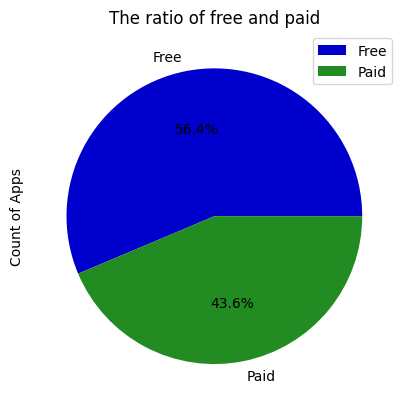

In [13]:
df3=df.groupby('type_app')['type_app'].count().reset_index(name='count')
display(df3)
df3.plot(kind='pie', y='count', labels=df3['type_app'], autopct='%1.1f%%',
         colors=['mediumblue', 'forestgreen'], ylabel='Count of Apps', title='The ratio of free and paid')
plt.show()

Grouping the data to calculate the number of free and paid applications for each genre.

Группировка данных позволяет рассчитать количество бесплатных и платных приложений для каждого жанра.

In [14]:
type_genres=df.groupby(['genre', 'type_app'])['title'].count().reset_index(name='count')
type_genres=type_genres.pivot_table(values='count', index='genre', columns='type_app').reset_index()
display(type_genres)

type_app,genre,Free,Paid
0,Book,66.0,46.0
1,Business,20.0,37.0
2,Catalogs,9.0,1.0
3,Education,132.0,321.0
4,Entertainment,334.0,201.0
5,Finance,84.0,20.0
6,Food & Drink,43.0,20.0
7,Games,2257.0,1605.0
8,Health & Fitness,76.0,104.0
9,Lifestyle,94.0,50.0


Visualizing the distribution of free and paid applications across different genres using a horizontal bar chart.

Визуализация распределения бесплатных и платных приложений по разным жанрам с помощью горизонтальной гистограммы.

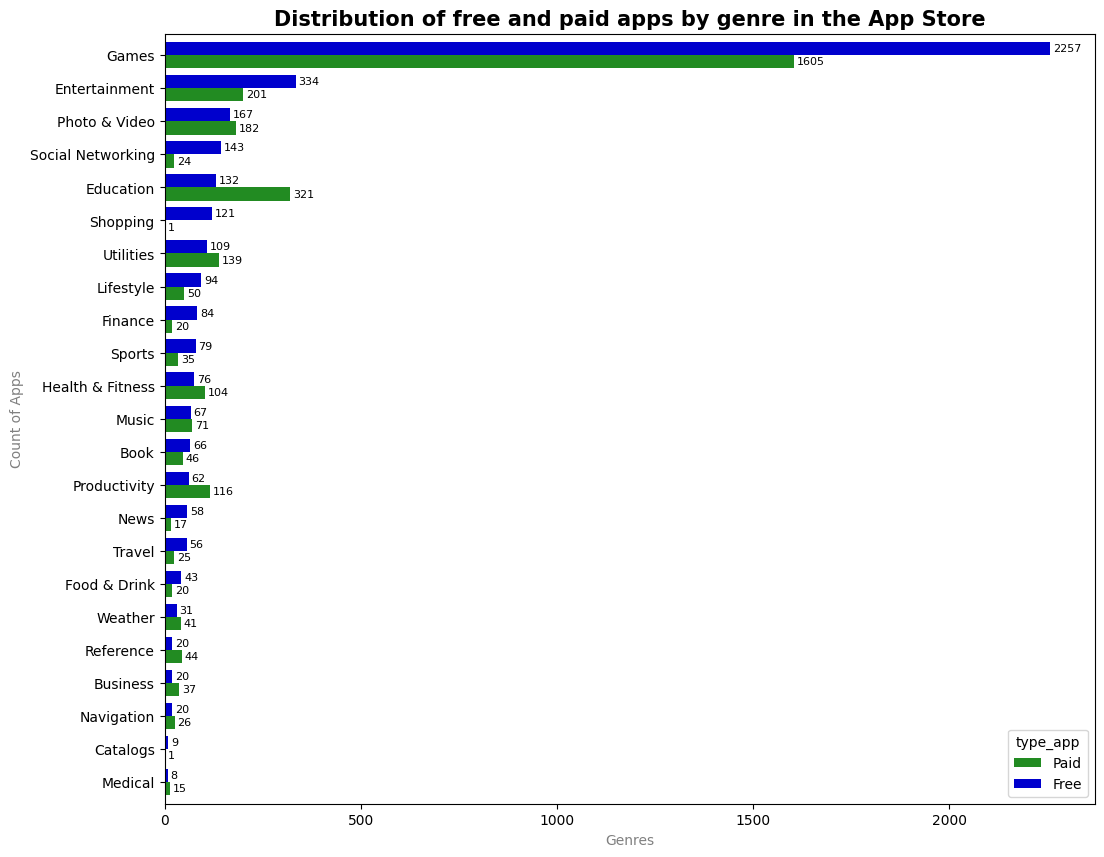

In [15]:
ax=type_genres.sort_values(by=['Free', 'Paid'], ascending=False)[::-1].plot(
    kind='barh', x='genre', y=['Paid', 'Free'], color=['forestgreen', 'mediumblue'], figsize=(12, 10), width=0.8)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)
plt.title('Distribution of free and paid apps by genre in the App Store', fontsize=15, fontweight='bold')
plt.xlabel('Genres', fontsize=10, color='grey')
plt.ylabel('Count of Apps', fontsize=10, color='grey')
plt.show()

Identifying and displaying the most popular application with the highest rating for each genre.

Определение и отображение самого популярного приложения с самым высоким рейтингом для каждого жанра.

In [16]:
group_columns1=['genre', 'count_rating_total', 'user_rating_total',
                'count_rating_version', 'user_rating_version']
df4=df.sort_values(by=group_columns1, ascending=False)
df4=df4.drop_duplicates(subset='genre', keep='first')
df4=df4[['id', 'title', 'size', 'price', 'user_rating_total', 'user_rating_version', 'genre']]
display(df4)

,id,title,size,price,user_rating_total,user_rating_version,genre
53,295646461,"The Weather Channel: Forecast, Radar & Alerts",199.73,0.00,3.5,4.5,Weather
12,284815942,Google – Search made just for mobile,179.98,0.00,3.5,4.0,Utilities
45,293622097,Google Earth,37.21,0.00,3.5,3.5,Travel
150,317469184,"ESPN: Get scores, news, alerts & watch live sp...",51.54,0.00,3.5,3.5,Sports
16,284882215,Facebook,389.88,0.00,3.5,3.5,Social Networking
317,352683833,"Groupon - Deals, Coupons & Discount Shopping App",127.38,0.00,4.5,4.5,Shopping
4,282935706,Bible,92.77,0.00,4.5,5.0,Reference
1,281796108,Evernote - stay organized,158.58,0.00,4.0,3.5,Productivity
519,389801252,Instagram,113.95,0.00,4.5,4.0,Photo & Video
221,333903271,Twitter,210.57,0.00,3.5,4.0,News


Identifying the top 20 most popular applications on the App Store based on total rating count.

Определение топ-20 самых популярных приложений в App Store на основе общего рейтинга.

In [17]:
top_apps=df.sort_values(by=group_columns1[1:], ascending=False)
display(top_apps.head(20))

,id,title,size,price,count_rating_total,count_rating_version,user_rating_total,user_rating_version,version,age_rating,genre,devices,screenshots,languages,vpp,description,type_app
16,284882215,Facebook,389.88,0.00,2974676,212,3.5,3.5,95.0,4+,Social Networking,37,1,29,True,Keeping up with friends is faster than ever. \...,Free
519,389801252,Instagram,113.95,0.00,2161558,1289,4.5,4.0,10.23,12+,Photo & Video,37,0,29,True,Instagram is a simple way to capture and share...,Free
1346,529479190,Clash of Clans,116.48,0.00,2130805,579,4.5,4.5,9.24.12,9+,Games,38,5,18,True,Join millions of players worldwide as you buil...,Free
707,420009108,Temple Run,65.92,0.00,1724546,3842,4.5,4.0,1.6.2,9+,Games,40,5,1,True,"""In pretty much every treasure hunting adventu...",Free
7,284035177,Pandora - Music & Radio,130.24,0.00,1126879,3594,4.0,4.5,8.4.1,12+,Music,37,4,1,True,Find the music you love and let the music you ...,Free
755,429047995,Pinterest,74.78,0.00,1061624,1814,4.5,4.0,6.26,12+,Social Networking,37,5,27,True,Pinterest is the world’s catalog of ideas. Fin...,Free
4,282935706,Bible,92.77,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,True,On more than 250 million devices around the wo...,Free
1493,553834731,Candy Crush Saga,222.85,0.00,961794,2453,4.5,4.5,1.101.0,4+,Games,43,5,24,True,"Candy Crush Saga, from the makers of Candy Cru...",Free
178,324684580,Spotify Music,132.51,0.00,878563,8253,4.5,4.5,8.4.3,12+,Music,37,5,18,True,Spotify is the best way to listen to music on ...,Free
275,343200656,Angry Birds,175.97,0.00,824451,107,4.5,3.0,7.4.0,4+,Games,38,0,10,True,Use the unique powers of the Angry Birds to de...,Free


Visualizing the top 20 most popular applications using a horizontal bar chart.

Визуализация топ-20 самых популярных приложений с помощью горизонтальной гистограммы.

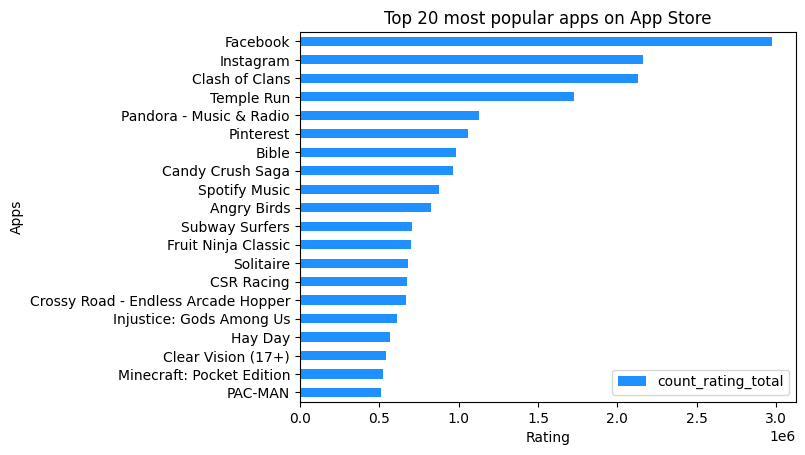

In [18]:
ax=top_apps.head(20)[::-1].plot(kind='barh', x='title', y='count_rating_total', color='dodgerblue')
plt.title('Top 20 most popular apps on App Store')
plt.xlabel('Rating')
plt.ylabel('Apps')
plt.show()

Visualizing the top 20 most popular free games on the App Store using a horizontal bar chart.

Визуализируйте топ-20 самых популярных бесплатных игр в App Store с помощью горизонтальной гистограммы.

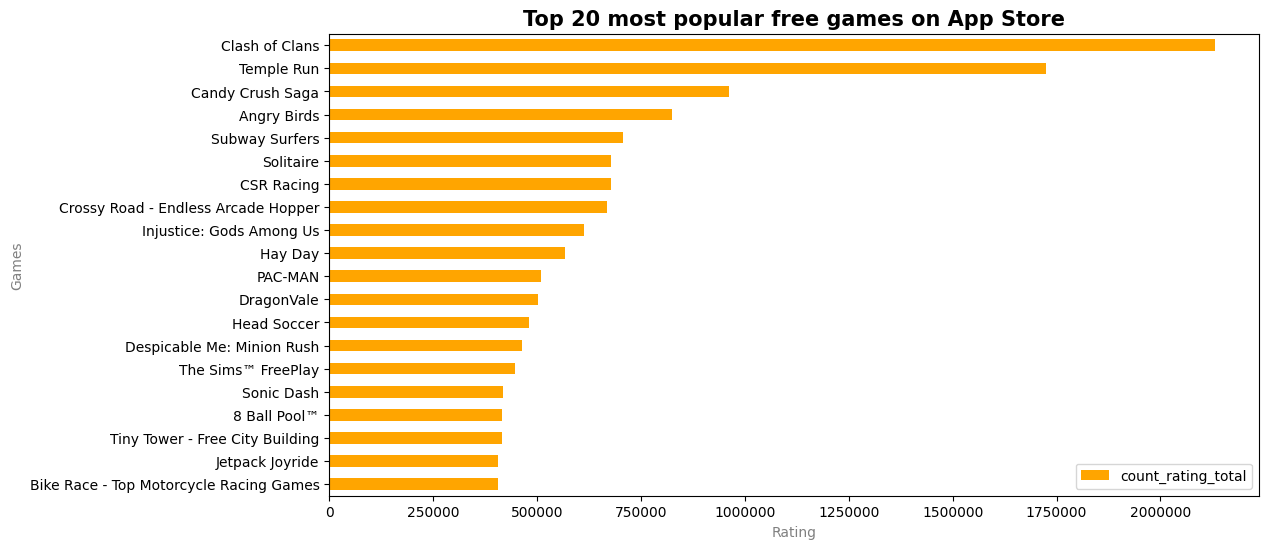

In [19]:
ax=top_apps[(top_apps['genre']=='Games') & (top_apps['type_app']=='Free')].head(20)[::-1].plot(
    kind='barh', x='title', y='count_rating_total', color='orange', figsize=(12, 6))
plt.title('Top 20 most popular free games on App Store', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize='10', color='grey')
plt.ylabel('Games', fontsize='10', color='grey')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

Visualizing the top 20 most popular paid games on the App Store using a horizontal bar chart.

Визуализируйте топ-20 самых популярных платных игр в App Store с помощью горизонтальной гистограммы.

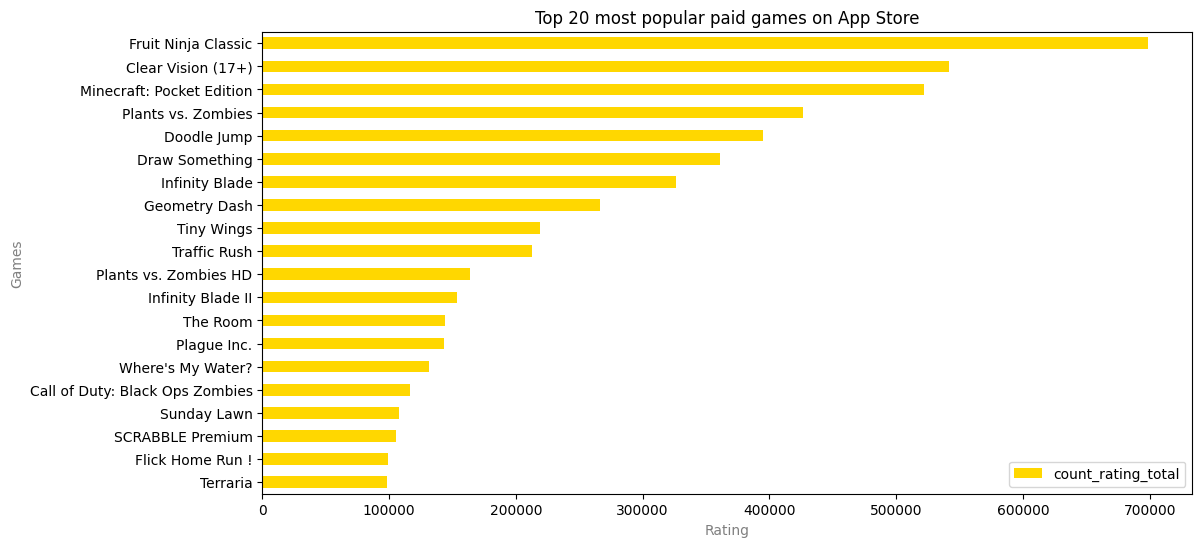

In [20]:
ax=top_apps[(top_apps['genre']=='Games') & (top_apps['type_app']=='Paid')].head(20)[::-1].plot(
    kind='barh', x='title', y='count_rating_total', color='gold', figsize=(12, 6))
plt.title('Top 20 most popular paid games on App Store')
plt.xlabel('Rating', fontsize='10', color='grey')
plt.ylabel('Games', fontsize='10', color='grey')
plt.show()

Sorting and visualizing the top 20 applications by their file size in gigabytes.

Сортировка и визуализация 20 лучших приложений по размеру их файлов в гигабайтах.

⚠️ This dataset contains many app titles in Chinese and Japanese. On the charts, some of these characters may appear as blank squares when running in cloud environments (Kaggle/Colab). This is a known technical limitation of the Kaggle and Google Colab platforms, which lack the required Asian fonts by default. Multiple workarounds were attempted (downloading font files, clearing the cache, installing system packages), but the platforms still throw an internal file format error. The code runs without this issue on a local PC. This does not affect the calculations or the analysis itself — all the code is correct.

⚠️ В этом датасете много названий приложений на китайском и японском языках. На графиках в облаке (Kaggle/Colab) вместо иероглифов могут отображаться пустые квадраты. Это известная техническая проблема самих платформ Kaggle и Google Colab, в которых нет нужных азиатских шрифтов. Было перепробовано множество способов это исправить (скачивание файлов шрифтов, очистка кэша, установка системных пакетов), но платформы всё равно выдают внутреннюю ошибку формата файла. На локальном компьютере код работает без этих проблем. На правильность расчетов и саму аналитику это никак не влияет — весь код написан верно.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12481 (\N{KATAKANA LETTER TI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

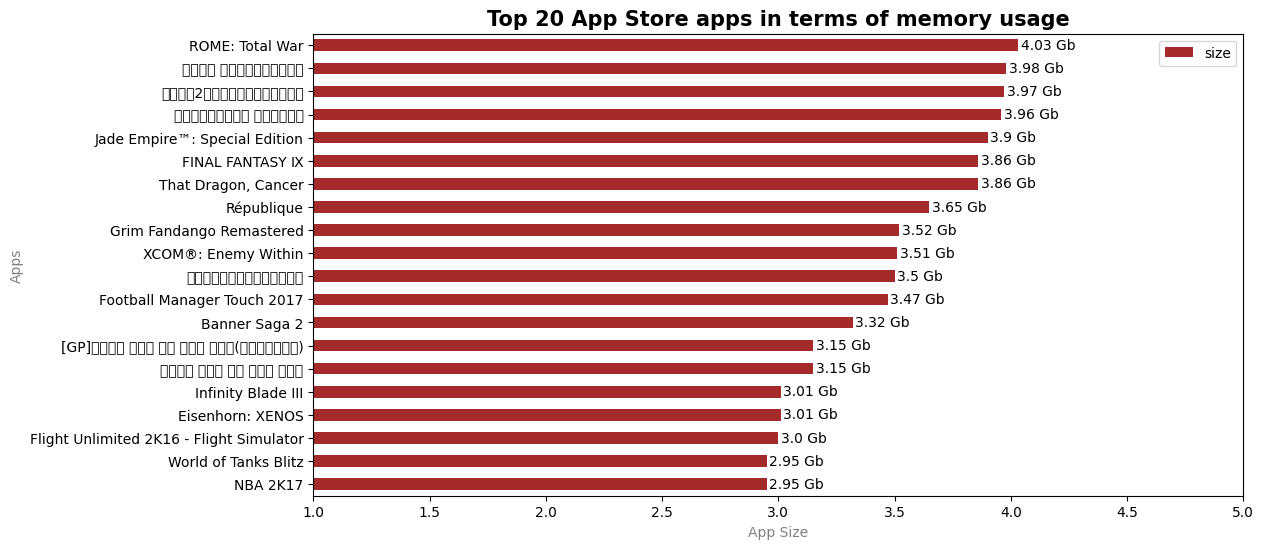

In [21]:
big_apps=df.sort_values(by='size', ascending=False).head(20)
big_apps['size']=np.round(big_apps['size']/1000, 2)
ax=big_apps[::-1].plot(kind='barh', x='title', y='size', color='brown', figsize=(12, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2, fmt='{} Gb')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Hiragino Sans', 'Heiti SC']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.title('Top 20 App Store apps in terms of memory usage', fontsize=15, fontweight='bold')
plt.xlabel('App Size', fontsize=10, color='grey')
plt.ylabel('Apps', fontsize=10, color='grey')
plt.xlim(1, 5)
plt.show()

Sorting and visualizing the top 20 most expensive paid applications.

Сортировка и визуализация топ-20 самых дорогих платных приложений.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12481 (\N{KATAKANA LETTER TI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12527 (\N{KATAKANA LETTER WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

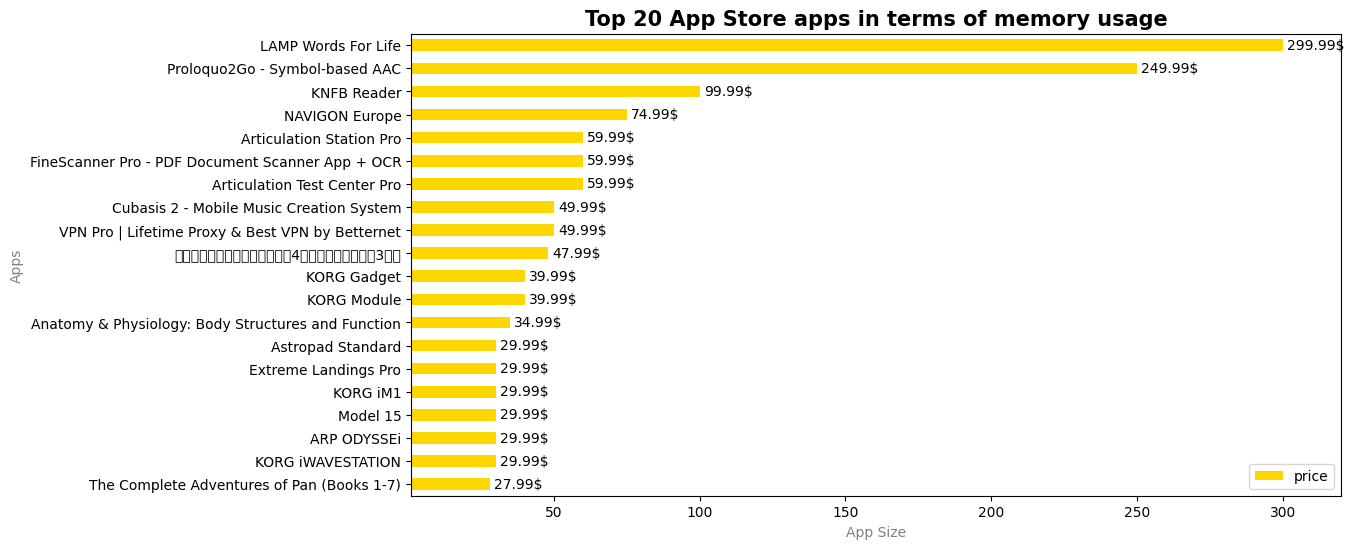

In [22]:
group_columns2=['price', 'count_rating_total', 'user_rating_total',
                'count_rating_version', 'user_rating_version']
top_price=df[df['type_app']=='Paid'].sort_values(by=group_columns2, ascending=False).head(20)
ax=top_price[::-1].plot(kind='barh', x='title', y='price', color='gold', figsize=(12, 6))
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{}$')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Hiragino Sans', 'Heiti SC']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.title('Top 20 App Store apps in terms of memory usage', fontsize=15, fontweight='bold')
plt.xlabel('App Size', fontsize=10, color='grey')
plt.ylabel('Apps', fontsize=10, color='grey')
plt.xlim(1, 320)
plt.show()

Calculating and visualizing the average price of paid applications for each genre.

Расчет и визуализация средней цены платных приложений для каждого жанра.

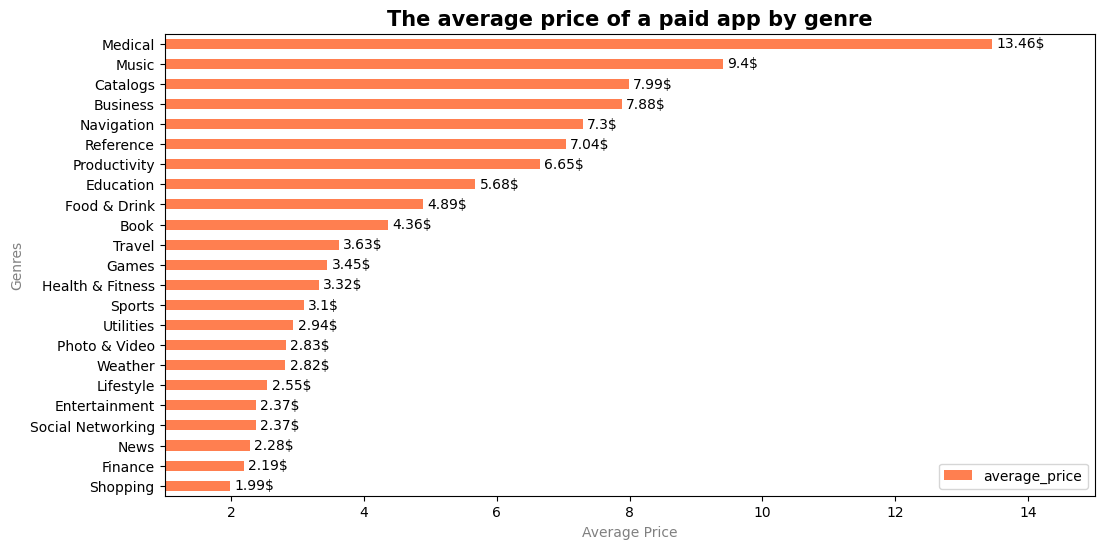

In [23]:
df5=df[df['type_app']=='Paid'].groupby('genre')['price'].mean()
df5=df5.reset_index(name='average_price').sort_values(by='average_price', ascending=False)
df5['average_price']=np.round(df5['average_price'], 2)
ax=df5[::-1].plot(kind='barh', x='genre', y='average_price', color='coral', figsize=(12, 6))
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{}$')
plt.title('The average price of a paid app by genre', fontsize=15, fontweight='bold')
plt.xlabel('Average Price', fontsize=10, color='grey')
plt.ylabel('Genres', fontsize=10, color='grey')
plt.xlim(1, 15)
plt.show()

Analyzing and visualizing the correlation between the number of supported languages and total application ratings.

Анализ и визуализация корреляции между количеством поддерживаемых языков и общим рейтингом приложений.

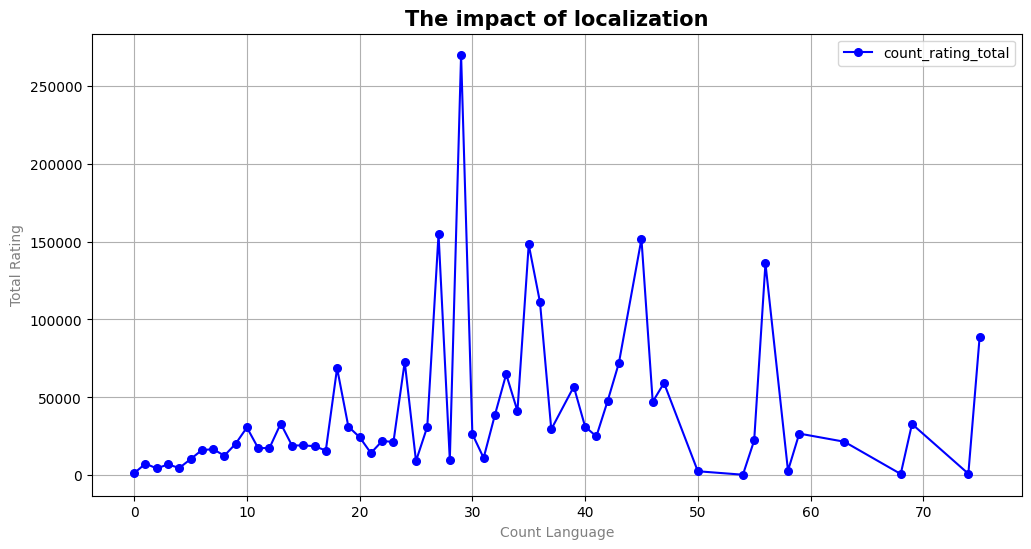

In [24]:
df6=df.groupby('languages', as_index=False)['count_rating_total'].mean()
df6.plot(kind='line', x='languages', y='count_rating_total', color='blue', figsize=(12, 6),
         marker='o', markersize=5.5)
plt.title('The impact of localization', fontsize=15, fontweight='bold')
plt.xlabel('Count Language', fontsize=10, color='grey')
plt.ylabel('Total Rating', fontsize=10, color='grey')
plt.grid()
plt.show()

Grouping and visualizing the distribution of applications based on age ratings using a vertical bar chart.

Группировка и визуализация распределения заявок по возрастным категориям с помощью вертикальной гистограммы.

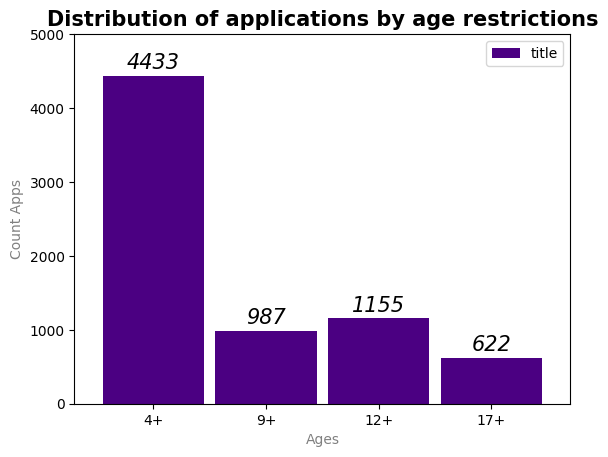

In [25]:
df7=df.groupby('age_rating', as_index=False)['title'].count()
df7=df7.set_index('age_rating').reindex(['4+', '9+', '12+', '17+']).reset_index()
ax=df7.plot(kind='bar', x='age_rating', y='title', width=0.9, color='indigo')
for container in ax.containers:
    ax.bar_label(container, padding=2, fontstyle='italic', fontsize=15, fontfamily='calibri')
plt.title('Distribution of applications by age restrictions', fontsize=15, fontweight='bold')
plt.xlabel('Ages', fontsize=10, color='grey')
plt.ylabel('Count Apps', fontsize=10, color='grey')
plt.ylim(0, 5000)
plt.xticks(rotation=0)
plt.show()

Creating a summary data series with key business metrics of the App Store dataset.

Создание сводного ряда данных с ключевыми бизнес-показателями из набора данных App Store.

In [26]:
info_appstore=pd.Series({
    'count_apps': df['title'].count(),
    'count_free_apps': df[df['type_app']=='Free']['title'].count(),
    'count_paid_apps': df[df['type_app']=='Paid']['title'].count(),
    'min_size': df['size'].min(),
    'average_size': df['size'].mean(),
    'max_size': df['size'].max(),
    'count_genre': df['genre'].nunique(),
    'count_age_rating': df['age_rating'].nunique(),
    'has_vpp': df[df['vpp']==True]['title'].count()
})
info_appstore=np.round(info_appstore, 2)
display(info_appstore)

,0
count_apps,7197.00
count_free_apps,4056.00
count_paid_apps,3141.00
min_size,0.59
average_size,199.13
max_size,4025.97
count_genre,23.00
count_age_rating,4.00
has_vpp,7147.00


Exporting the final cleaned dataset to a CSV file for further analytical use.

Экспорт окончательного очищенного набора данных в CSV-файл для дальнейшего аналитического использования.

In [27]:
df.to_csv('appstore_analysis.csv', index=False)